# Transdukcyjne Maszyny Wektorów Nośnych (TSVM)

Transdukcyjne SVM (TSVM) to rozszerzenie klasycznego SVM, które jednocześnie uczy parametry klasyfikatora i przypisuje (miękkie) etykiety dla próbek nieetykietowanych. Główną ideą jest wykorzystanie struktury rozkładu danych (np. klastrów i gęstości) do poprawy klasyfikacji na punktach bez etykiet.

W uproszczonej postaci problem optymalizacji można zapisać jako:

$$\min_{w,b,\eta,\xi} \left[ \|w\|^2 + C_L \sum_{i=1}^{N} \eta_i + C_U \sum_{j=N+1}^{N+M} \xi_j\right]$$

gdzie $\eta_i$ i $\xi_j$ to zmienne miękkie (slack) odpowiadające karom dla próbek etykietowanych i nieetykietowanych, a $C_L, C_U$ sterują kompromisem między maksymalizacją marginesu a dopasowaniem do danych.

Ograniczenia są podobne do tych w klasycznym SVM: dla etykietowanych próbek wymagamy $y_i (w^T x_i + b) \ge 1 - \eta_i$ z $\eta_i \ge 0$. Dla próbek nieetykietowanych wprowadza się warunki zależne od (pseudo-)etykiet, które implikują analogiczne nierówności po jednej ze stron (dla +1 lub -1) oraz ograniczenia na zmienne kar.

Uwagi praktyczne:

- TSVM działa dobrze, gdy nieetykietowany zbiór jest względnie wiarygodny i odzwierciedla strukturę klas.
- W praktyce optymalizacja jest nieliniowa i może być wielomodalna — wyniki zależą od inicjalizacji oraz wyboru $C_L$ i $C_U$.
- Dla szybkich demonstracji na zajęciach zmniejsz `nb_samples` lub ustaw mniejszy `maxiter` w wywołaniu `minimize` (optymalizator może być wolny).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.datasets import make_classification

In [2]:
np.random.seed(1000)
nb_samples = 200
nb_unlabeled = 150
X, Y = make_classification(n_samples=nb_samples, n_features=2, n_redundant=0, random_state=1000)
Y[Y == 0] = -1
Y[nb_samples - nb_unlabeled : nb_samples] = 0

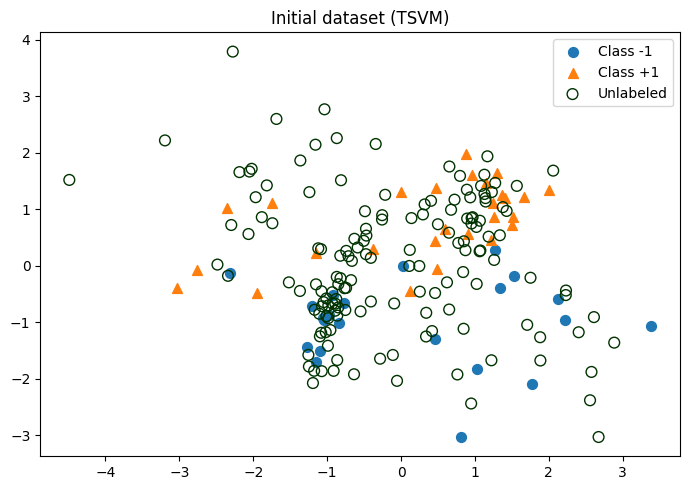

In [3]:
plt.figure(figsize=(7,5))
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], marker='o', s=50, label='Class -1')
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], marker='^', s=50, label='Class +1')
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], facecolor='none', edgecolor='#003200', marker='o', s=60, label='Unlabeled')
plt.legend()
plt.title('Initial dataset (TSVM)')
plt.tight_layout()

In [4]:
w = np.random.uniform(-0.1, 0.1, size=X.shape[1])
eta_labeled = np.random.uniform(0.0, 0.1, size=nb_samples - nb_unlabeled)
eta_unlabeled = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
y_unlabeled = np.random.uniform(-1.0, 1.0, size=nb_unlabeled)
b = np.random.uniform(-0.1, 0.1, size=1)
C_labeled = 2.0
C_unlabeled = 0.1

In [5]:
theta0 = np.hstack((w, eta_labeled, eta_unlabeled, y_unlabeled, b))

In [6]:
def svm_target(theta, Xd, Yd):
    wt = theta[0:2].reshape((Xd.shape[1], 1))
    s_eta_labeled = np.sum(theta[2 : 2 + nb_samples - nb_unlabeled])
    s_eta_unlabeled = np.sum(theta[2 + nb_samples - nb_unlabeled : 2 + nb_samples])
    return (C_labeled * s_eta_labeled) + (C_unlabeled * s_eta_unlabeled) + (0.5 * np.dot(wt.T, wt))

In [7]:
def labeled_constraint(theta, Xd, Yd, idx):
    wt = theta[0:2].reshape((Xd.shape[1], 1))
    c = (Yd[idx] * (np.dot(Xd[idx], wt) + theta[-1]) + theta[2 : 2 + nb_samples - nb_unlabeled][idx] - 1.0)
    return int((c >= 0)[0])

In [8]:
def unlabeled_constraint(theta, Xd, idx):
    wt = theta[0:2].reshape((Xd.shape[1], 1))
    c = (theta[2 + nb_samples : 2 + nb_samples + nb_unlabeled][idx - nb_samples + nb_unlabeled] * (np.dot(Xd[idx], wt) + theta[-1]) + theta[2 + nb_samples - nb_unlabeled : 2 + nb_samples][idx - nb_samples + nb_unlabeled] - 1.0)
    return int((c >= 0)[0])

In [9]:
def eta_labeled_constraint(theta, idx):
    return int(theta[2 : 2 + nb_samples - nb_unlabeled][idx] >= 0)

In [10]:
def eta_unlabeled_constraint(theta, idx):
    return int(theta[2 + nb_samples - nb_unlabeled : 2 + nb_samples][idx - nb_samples + nb_unlabeled] >= 0)

In [11]:
svm_constraints = []
for i in range(nb_samples - nb_unlabeled):
    svm_constraints.append({'type': 'ineq', 'fun': labeled_constraint, 'args': (X, Y, i)})
    svm_constraints.append({'type': 'ineq', 'fun': eta_labeled_constraint, 'args': (i,)})
for i in range(nb_samples - nb_unlabeled, nb_samples):
    svm_constraints.append({'type': 'ineq', 'fun': unlabeled_constraint, 'args': (X, i)})
    svm_constraints.append({'type': 'ineq', 'fun': eta_unlabeled_constraint, 'args': (i,)})

In [12]:
result = minimize(fun=svm_target,
                  x0=theta0,
                  constraints=svm_constraints,
                  args=(X, Y), method='SLSQP',
                  tol=0.0001,
                  options={'maxiter': 1000},
                  )

In [13]:
theta_end = result['x']
w_end = theta_end[0:2]
b_end = theta_end[-1]
Xu = X[nb_samples - nb_unlabeled : nb_samples]
yu = -np.sign(np.dot(Xu, w_end) + b_end)

# Wykres wyniku

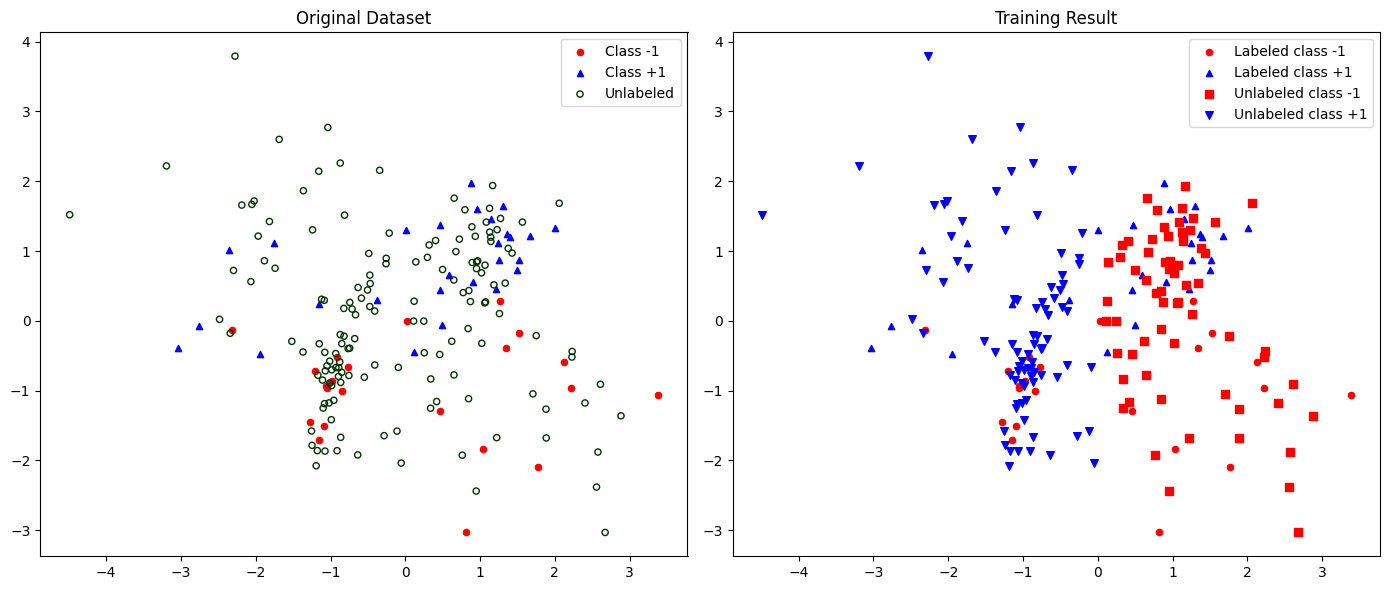

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].scatter(X[Y == -1, 0], X[Y == -1, 1], marker='o', c='r', s=20, label='Class -1')
ax[0].scatter(X[Y == 1, 0], X[Y == 1, 1], marker='^', s=20, c='b', label='Class +1')
ax[0].scatter(X[Y == 0, 0], X[Y == 0, 1], facecolor='none', edgecolor='#003200', marker='o', s=20, label='Unlabeled')
ax[0].legend()
ax[0].set_title("Original Dataset")

ax[1].scatter(X[Y == -1, 0], X[Y == -1, 1], c='r', marker='o', s=20, label='Labeled class -1')
ax[1].scatter(X[Y == 1, 0], X[Y == 1, 1], c='b', marker='^', s=20, label='Labeled class +1')
ax[1].scatter(Xu[yu == -1, 0], Xu[yu == -1, 1], c='r', marker='s', s=30, label='Unlabeled class -1')
ax[1].scatter(Xu[yu == 1, 0], Xu[yu == 1, 1], c='b', marker='v', s=30, label='Unlabeled class +1')
ax[1].legend()
ax[1].set_title("Training Result")

plt.tight_layout()

## Zadania ćwiczeniowe — TSVM (do wykonania po uruchomieniu)

In [15]:
# Zadanie 1: Wpływ C_labeled i C_unlabeled
C_pairs = [(1.0, 0.1), (2.0, 0.1), (5.0, 0.5)]
results = {}
for C_lab, C_unlab in C_pairs:
    C_labeled = C_lab
    C_unlabeled = C_unlab
    w = np.random.uniform(-0.1, 0.1, size=X.shape[1])
    eta_labeled = np.random.uniform(0.0, 0.1, size=nb_samples - nb_unlabeled)
    eta_unlabeled = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
    y_unlabeled = np.random.uniform(-1.0, 1.0, size=nb_unlabeled)
    b = np.random.uniform(-0.1, 0.1, size=1)
    theta0 = np.hstack((w, eta_labeled, eta_unlabeled, y_unlabeled, b))
    svm_constraints = []
    for i in range(nb_samples - nb_unlabeled):
        svm_constraints.append({'type': 'ineq', 'fun': labeled_constraint, 'args': (X, Y, i)})
        svm_constraints.append({'type': 'ineq', 'fun': eta_labeled_constraint, 'args': (i,)})
    for i in range(nb_samples - nb_unlabeled, nb_samples):
        svm_constraints.append({'type': 'ineq', 'fun': unlabeled_constraint, 'args': (X, i)})
        svm_constraints.append({'type': 'ineq', 'fun': eta_unlabeled_constraint, 'args': (i,)})
    result = minimize(fun=svm_target, x0=theta0, constraints=svm_constraints, args=(X, Y), method='SLSQP', tol=0.0001, options={'maxiter': 1000})
    theta_end = result['x']
    w_end = theta_end[0:2]
    b_end = theta_end[-1]
    Xu = X[nb_samples - nb_unlabeled : nb_samples]
    yu = -np.sign(np.dot(Xu, w_end) + b_end)
    results[(C_lab, C_unlab)] = yu
for k, yu_pred in results.items():
    print(f'C_labeled={k[0]}, C_unlabeled={k[1]}: liczba +1: {(yu_pred == 1).sum()}, liczba -1: {(yu_pred == -1).sum()}')

C_labeled=1.0, C_unlabeled=0.1: liczba +1: 69, liczba -1: 81
C_labeled=2.0, C_unlabeled=0.1: liczba +1: 82, liczba -1: 68
C_labeled=5.0, C_unlabeled=0.5: liczba +1: 72, liczba -1: 78


In [16]:
# Zadanie 2: Zmiana liczby punktów nieetykietowanych
for nb_unl in [20, 80, 150]:
    nb_unlabeled = nb_unl
    nb_samples = 200
    X, Y = make_classification(n_samples=nb_samples, n_features=2, n_redundant=0, random_state=1000)
    Y[Y == 0] = -1
    Y[nb_samples - nb_unlabeled : nb_samples] = 0
    w = np.random.uniform(-0.1, 0.1, size=X.shape[1])
    eta_labeled = np.random.uniform(0.0, 0.1, size=nb_samples - nb_unlabeled)
    eta_unlabeled = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
    y_unlabeled = np.random.uniform(-1.0, 1.0, size=nb_unlabeled)
    b = np.random.uniform(-0.1, 0.1, size=1)
    theta0 = np.hstack((w, eta_labeled, eta_unlabeled, y_unlabeled, b))
    svm_constraints = []
    for i in range(nb_samples - nb_unlabeled):
        svm_constraints.append({'type': 'ineq', 'fun': labeled_constraint, 'args': (X, Y, i)})
        svm_constraints.append({'type': 'ineq', 'fun': eta_labeled_constraint, 'args': (i,)})
    for i in range(nb_samples - nb_unlabeled, nb_samples):
        svm_constraints.append({'type': 'ineq', 'fun': unlabeled_constraint, 'args': (X, i)})
        svm_constraints.append({'type': 'ineq', 'fun': eta_unlabeled_constraint, 'args': (i,)})
    result = minimize(fun=svm_target, x0=theta0, constraints=svm_constraints, args=(X, Y), method='SLSQP', tol=0.0001, options={'maxiter': 1000})
    theta_end = result['x']
    w_end = theta_end[0:2]
    b_end = theta_end[-1]
    Xu = X[nb_samples - nb_unlabeled : nb_samples]
    yu = -np.sign(np.dot(Xu, w_end) + b_end)
    print(f'nb_unlabeled={nb_unl}: liczba +1: {(yu == 1).sum()}, liczba -1: {(yu == -1).sum()}')

nb_unlabeled=20: liczba +1: 8, liczba -1: 12
nb_unlabeled=80: liczba +1: 38, liczba -1: 42
nb_unlabeled=80: liczba +1: 38, liczba -1: 42
nb_unlabeled=150: liczba +1: 70, liczba -1: 80
nb_unlabeled=150: liczba +1: 70, liczba -1: 80


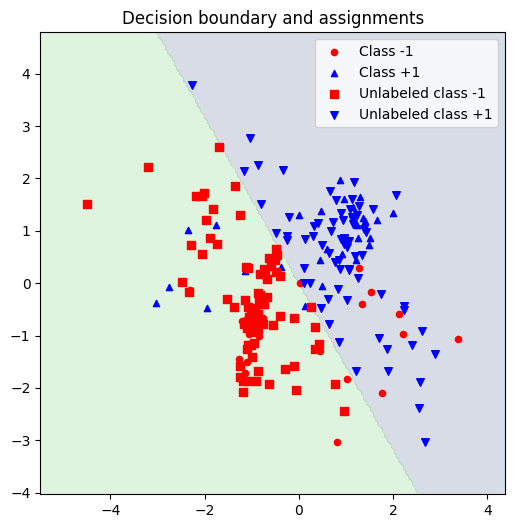

In [17]:
# Zadanie 3: Granica decyzyjna (decision boundary)
xx_min, xx_max = X[:,0].min() - 1, X[:,0].max() + 1
yy_min, yy_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 200), np.linspace(yy_min, yy_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.dot(grid, w_end) + b_end
Z = Z.reshape(xx.shape)
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, np.sign(Z), alpha=0.2, levels=[-1,0,1])
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], marker='o', c='r', s=20, label='Class -1')
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], marker='^', s=20, c='b', label='Class +1')
plt.scatter(Xu[yu == -1, 0], Xu[yu == -1, 1], c='r', marker='s', s=30, label='Unlabeled class -1')
plt.scatter(Xu[yu == 1, 0], Xu[yu == 1, 1], c='b', marker='v', s=30, label='Unlabeled class +1')
plt.legend()
plt.title('Decision boundary and assignments')
plt.show()

In [18]:
# Zadanie 4: Punkty najbliżej granicy (analiza marginesu)
margins = np.abs(np.dot(Xu, w_end) + b_end) / np.linalg.norm(w_end)
idx = np.argsort(margins)
print('5 punktów najbliższych granicy:')
print(Xu[idx[:5]])
print('Marginesy:', margins[idx[:5]])

5 punktów najbliższych granicy:
[[ 2.53756095e-01 -4.57555951e-01]
 [-1.68630379e+00  2.59973855e+00]
 [-4.74596011e-01  6.54957229e-01]
 [ 1.11458179e-01 -3.13140909e-03]
 [-2.27723196e+00  3.79197431e+00]]
Marginesy: [0.02997152 0.04274941 0.05356615 0.09173441 0.09242587]
